In [236]:
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sys.path.append(r"D:/Football Project/src")

import feature_lists_3yr as fl

In [237]:
df=pd.read_csv("D:/Football Project/data/processed/3_year/EWMA_Top5_Leagues.csv")

In [238]:
df=df[df['position']=='Midfielders']

In [239]:
df=df[df['minutesplayed'] > 540]

In [240]:
df.shape

(780, 207)

In [241]:
df=df.drop(columns=fl.goalkeeper_features)

In [242]:
df=df.drop(columns=fl.discipline_features)

In [243]:
volume_drops = [
    # General Playing Time
    'appearances', 'matchesstarted', 'totwappearances',
    
    # Attacking & Goals Volume
    'goals', 'assists', 'expectedgoals', 'expectedassists', 'goalsassistssum',
    'totalshots', 'shotsfrominsidethebox', 'shotsfromoutsidethebox', 
    'shotsontarget', 'shotsofftarget', 'bigchancescreated', 'bigchancesmissed',
    'goalsfrominsidethebox', 'goalsfromoutsidethebox', 'headedgoals', 
    'leftfootgoals', 'rightfootgoals', 'freekickgoal', 'penaltygoals', 'penaltiestaken',
    'hitwoodwork', 'blockedshots',
    
    # Passing & Possession Volume
    'touches', 'totalpasses', 'accuratepasses', 'inaccuratepasses',
    'totalownhalfpasses', 'accurateownhalfpasses', 
    'totaloppositionhalfpasses', 'accurateoppositionhalfpasses',
    'accuratefinalthirdpasses', 'totalattemptassist', 'passtoassist',
    'keypasses', 'totalcross', 'accuratecrosses', 'totallongballs', 'accuratelongballs', 
    'totalchippedpasses', 'accuratechippedpasses', 'possessionlost',
    
    # Defending & Duels Volume
    'totalduelswon', 'groundduelswon', 'aerialduelswon', 'aeriallost', 'duellost',
    'interceptions', 'ballrecovery', 'defensive_actions', 'clearances', 'fouls',
    'tackles', 'tackleswon', 'dribbledpast', 'errorleadtoshot', 'errorleadtogoal',
    
    # Dribbling & Flank Volume
    'successfuldribbles', 'dispossessed', 'wasfouled', 'totalcontest', 'offsides'
]

In [244]:
df=df.drop(columns=volume_drops)

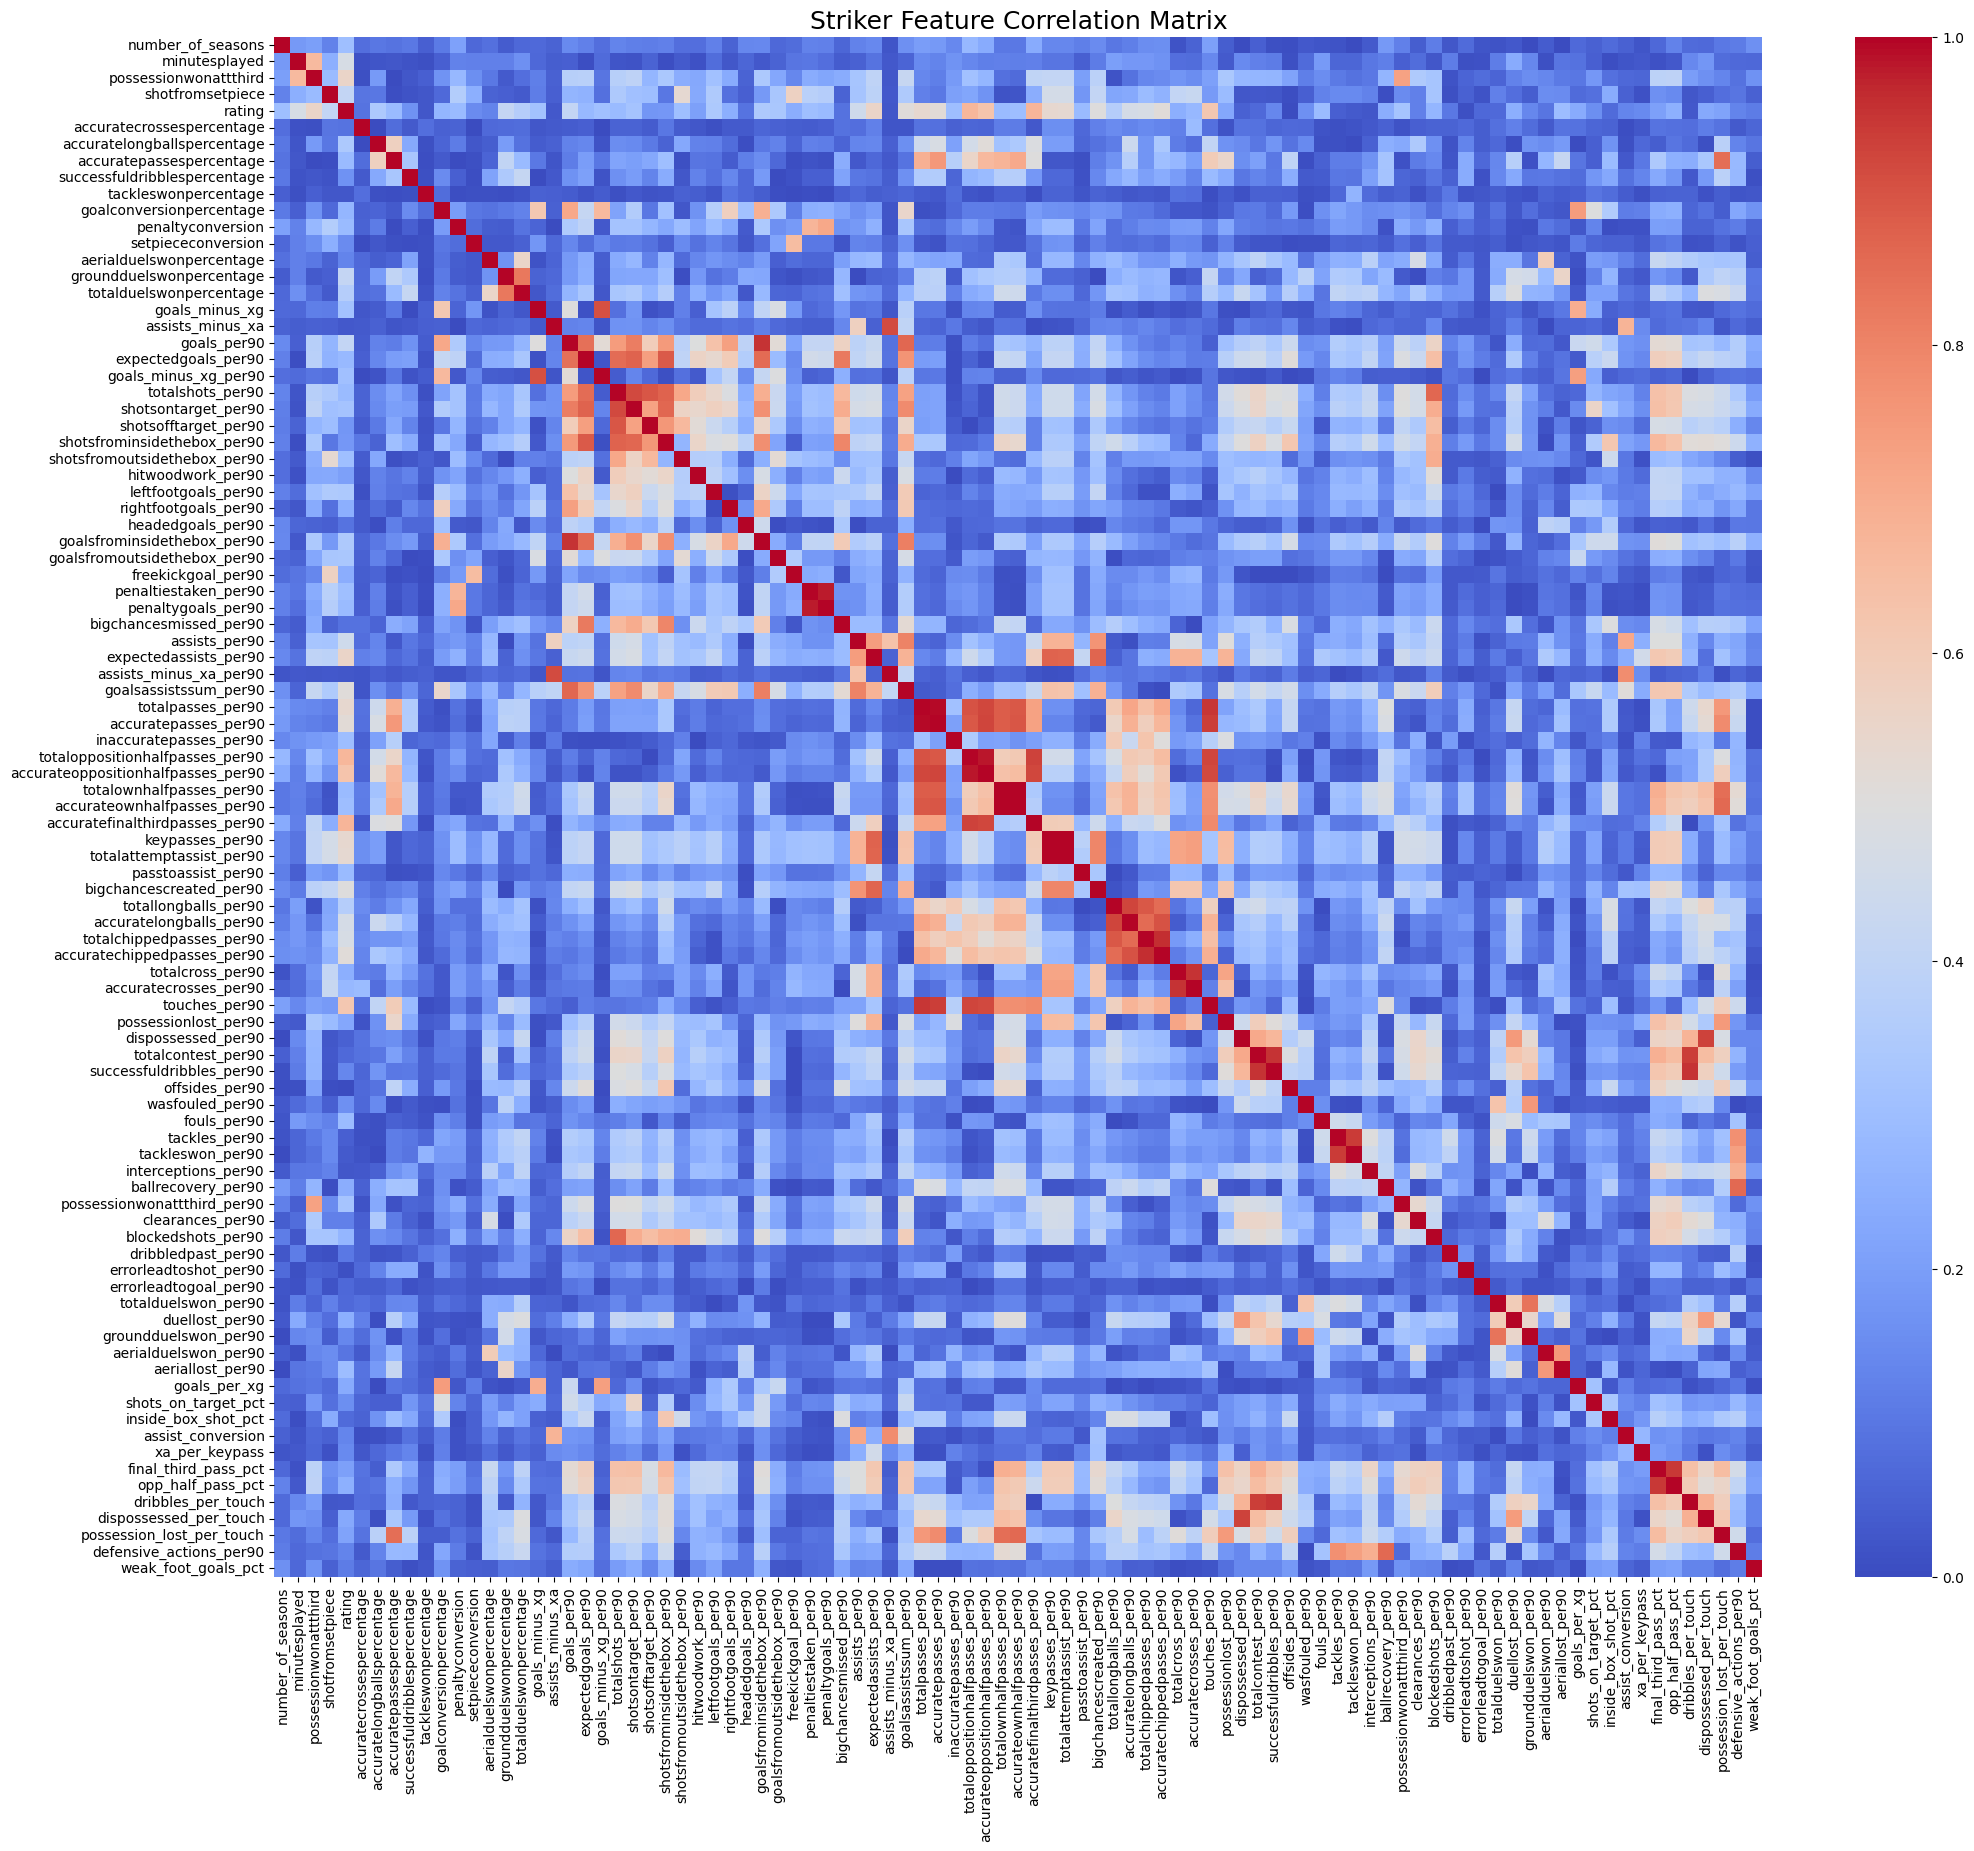

In [245]:
corr_matrix = df.drop(columns=fl.metadata_features).corr().abs()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Striker Feature Correlation Matrix", fontsize=18)
plt.show()

In [246]:
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(corr_pairs > 0.80) & (corr_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)

high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(high_corr_df)

,Feature_1,Feature_2,Correlation
0,keypasses_per90,totalattemptassist_per90,0.999568
1,totalownhalfpasses_per90,accurateownhalfpasses_per90,0.997679
2,totalpasses_per90,accuratepasses_per90,0.994119
3,totaloppositionhalfpasses_per90,accurateoppositionhalfpasses_per90,0.983828
4,penaltiestaken_per90,penaltygoals_per90,0.978635
5,totalchippedpasses_per90,accuratechippedpasses_per90,0.958416
6,goals_per90,goalsfrominsidethebox_per90,0.953028
7,totalcontest_per90,successfuldribbles_per90,0.952443
8,totalcross_per90,accuratecrosses_per90,0.951114
9,successfuldribbles_per90,dribbles_per_touch,0.949464


In [247]:
drop=['totalattemptassist_per90','totalownhalfpasses_per90','totalpasses_per90',
      'totaloppositionhalfpasses_per90','penaltiestaken_per90','penaltygoals_per90',
      'totalchippedpasses_per90','totalcontest_per90','totalcross_per90',
      'tackles_per90','opp_half_pass_pct','dispossessed_per90','totalshots_per90',
      'accurateoppositionhalfpasses_per90','totallongballs_per90','goalsassistssum_per90',
      'goals_minus_xg','assists_minus_xa','expectedassists_per90','touches_per90',
      'accurateownhalfpasses_per90','goalsfrominsidethebox_per90','shotsfrominsidethebox_per90',
      'shotsontarget_per90','bigchancesmissed_per90','ballrecovery_per90','totalduelswon_per90',
      'totalduelswonpercentage','dribbles_per_touch','accuratechippedpasses_per90']

In [248]:
df=df.drop(columns=drop)

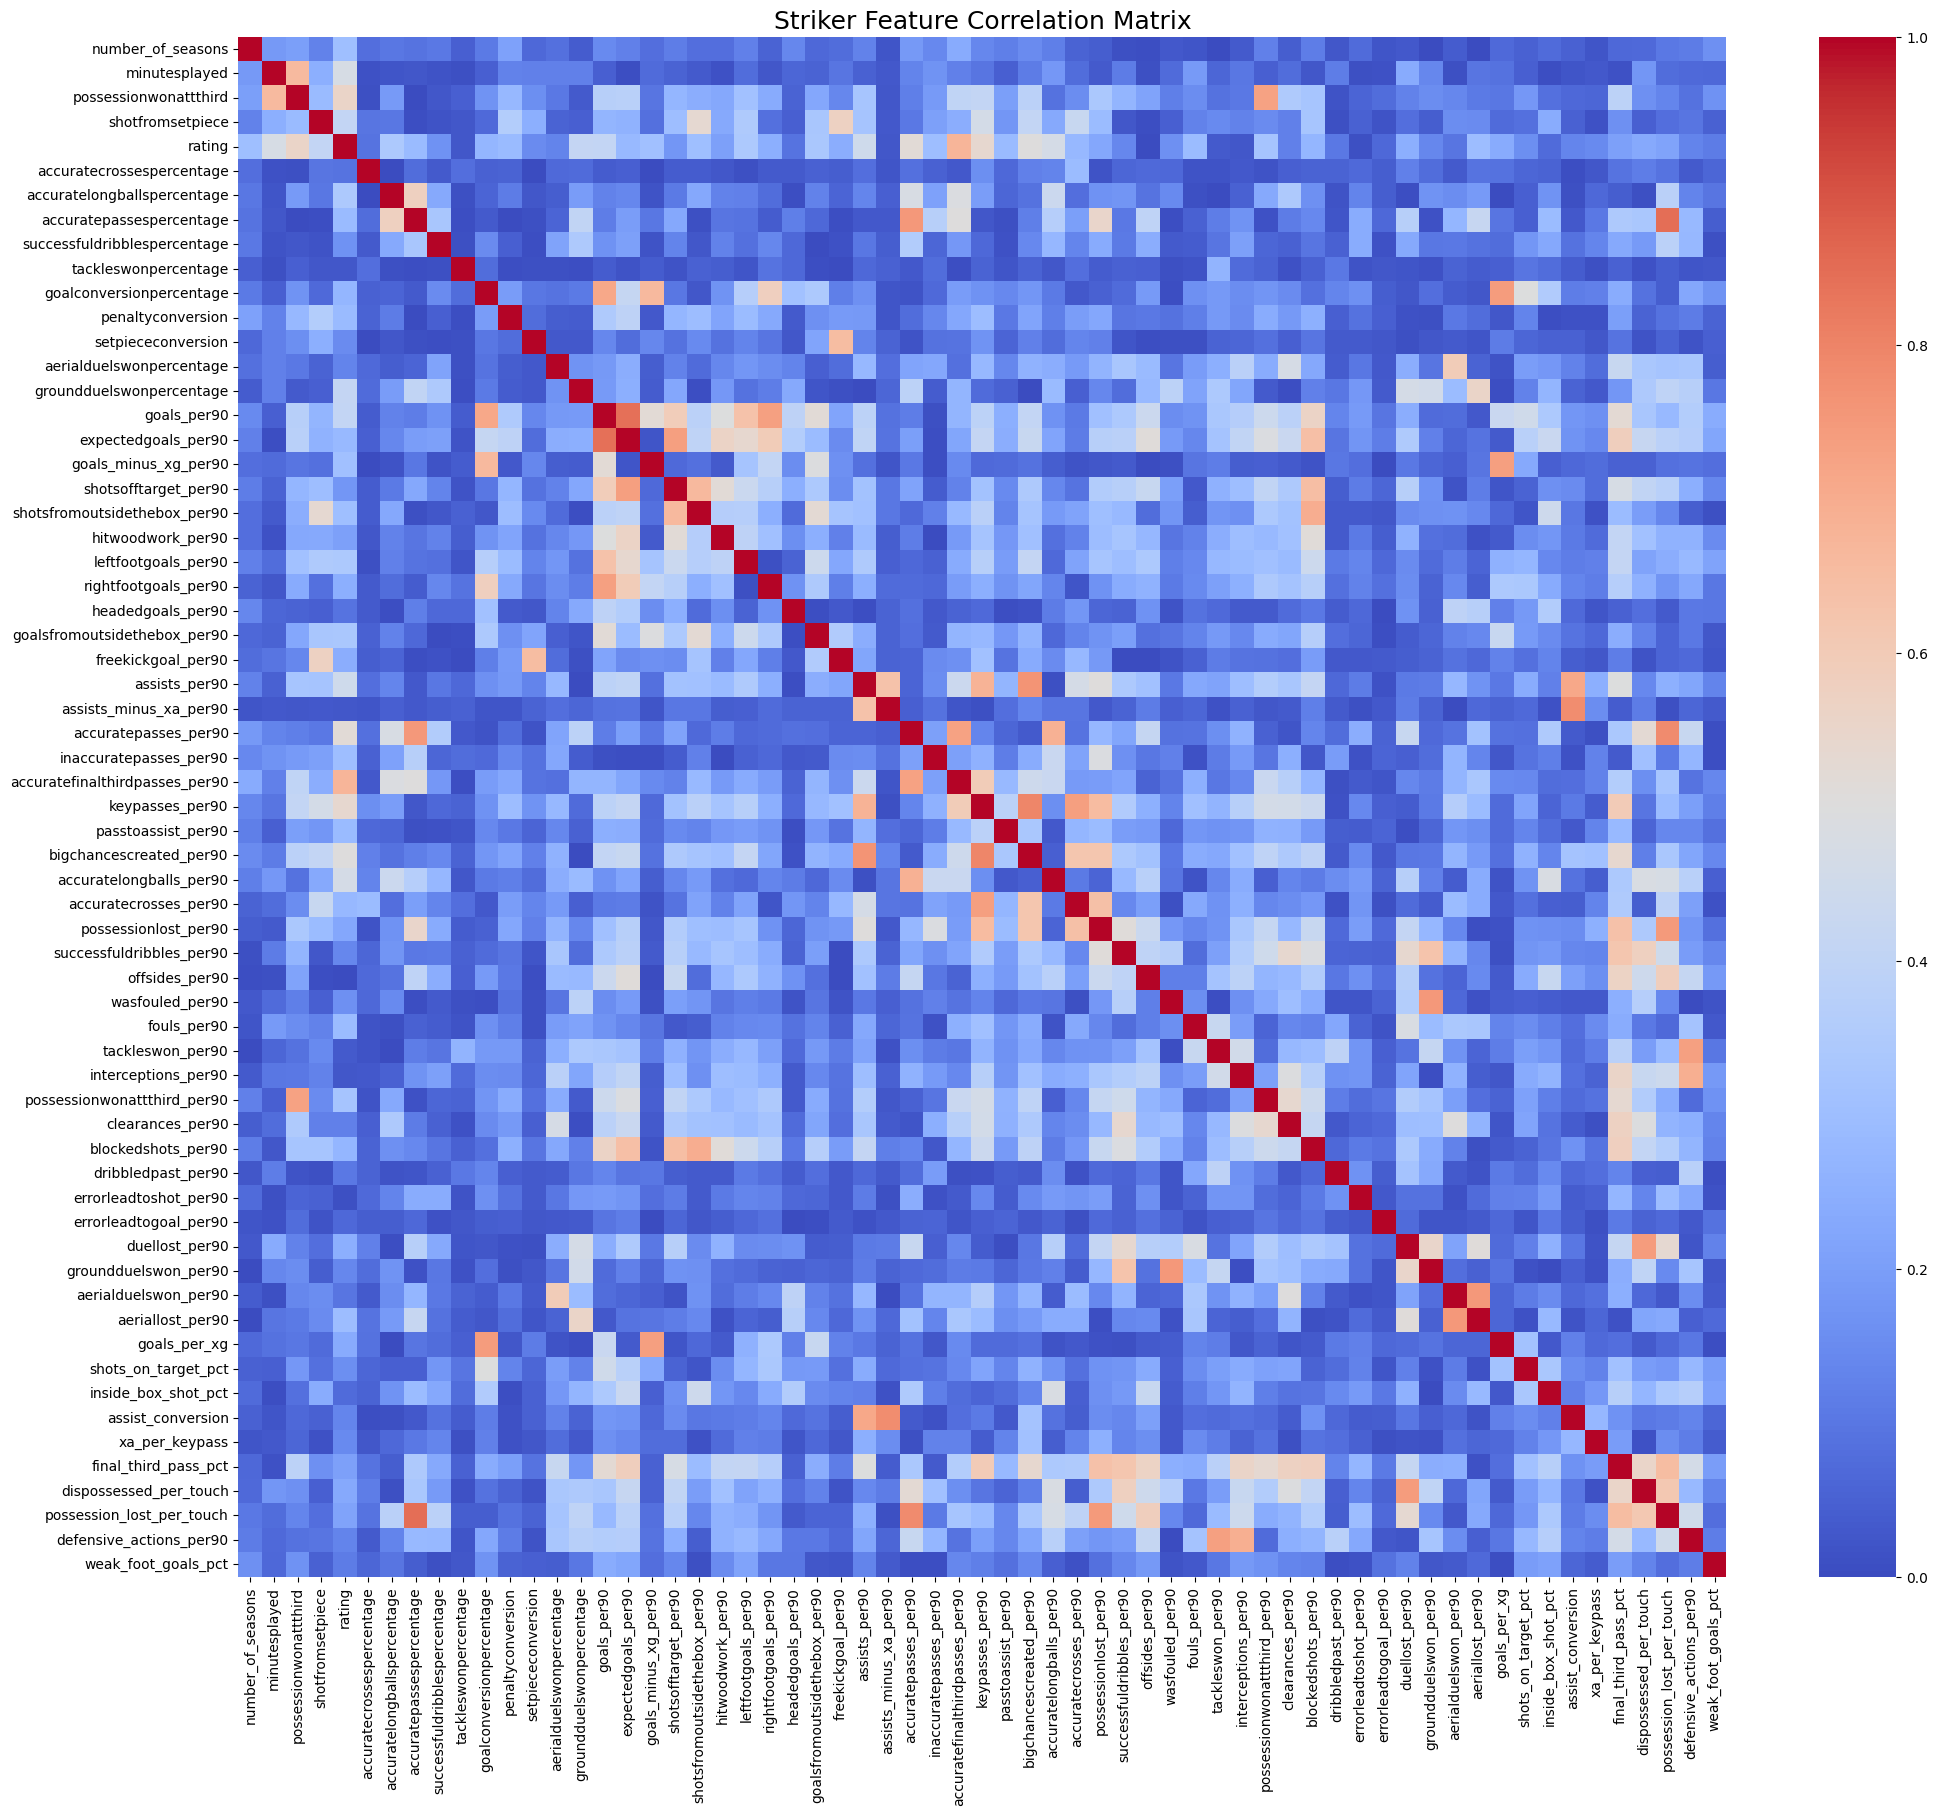

In [249]:
corr_matrix = df.drop(columns=fl.metadata_features).corr().abs()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Striker Feature Correlation Matrix", fontsize=18)
plt.show()

In [250]:
df.shape

(780, 69)

In [251]:
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(corr_pairs > 0.80) & (corr_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)

high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(high_corr_df)

,Feature_1,Feature_2,Correlation
0,accuratepassespercentage,possession_lost_per_touch,0.844708
1,goals_per90,expectedgoals_per90,0.840531


In [252]:
targets=['Pedri','Lamine Yamal','Kevin De Bruyne','Michael Olise','Rodri','Jude Bellingham','Cole Palmer','Declan Rice','Bruno Fernandes','Vitinha','João Neves','Pablo Gavi']
view_df=df.copy()
view_df['highlight'] = view_df['player'].isin(targets).astype(int)

In [255]:
fig = px.scatter(
    view_df.copy(), 
    x='defensive_actions_per90', 
    y='bigchancescreated_per90',
    color='highlight',
    hover_name='player',         
    hover_data=['team','number_of_seasons'], 
    title='Midfielders Performance',
    labels={
        'minutesplayed': 'Minutes Played',
    },
    template='plotly_white',               
    width=1000, 
    height=600
)

fig.update_traces(marker=dict(size=10, opacity=0.8, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

In [254]:
df.to_csv('../../../data/processed/3_year/Midfielders/EWMA_Top5_Midfielders.csv',index=False)